## Q13 - HR Employee Data EDA & Analysis

--- Dataset Shape ---
Total employees: 14999
Total features: 11

--- Missing Values ---
Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

Overall Turnover Rate: 23.8%

--- Profile of 'Burnout' employees leaving ---
Average projects: 6.2
Average monthly hours: 276


C:\Users\OGK19\AppData\Local\Temp\ipykernel_22620\1973472413.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='salary', y='left', order=['low', 'medium', 'high'],
C:\Users\OGK19\AppData\Local\Temp\ipykernel_22620\1973472413.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='number_project', y='left', errorbar=None,
C:\Users\OGK19\AppData\Local\Temp\ipykernel_22620\1973472413.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Department', y='left', errorbar=None,


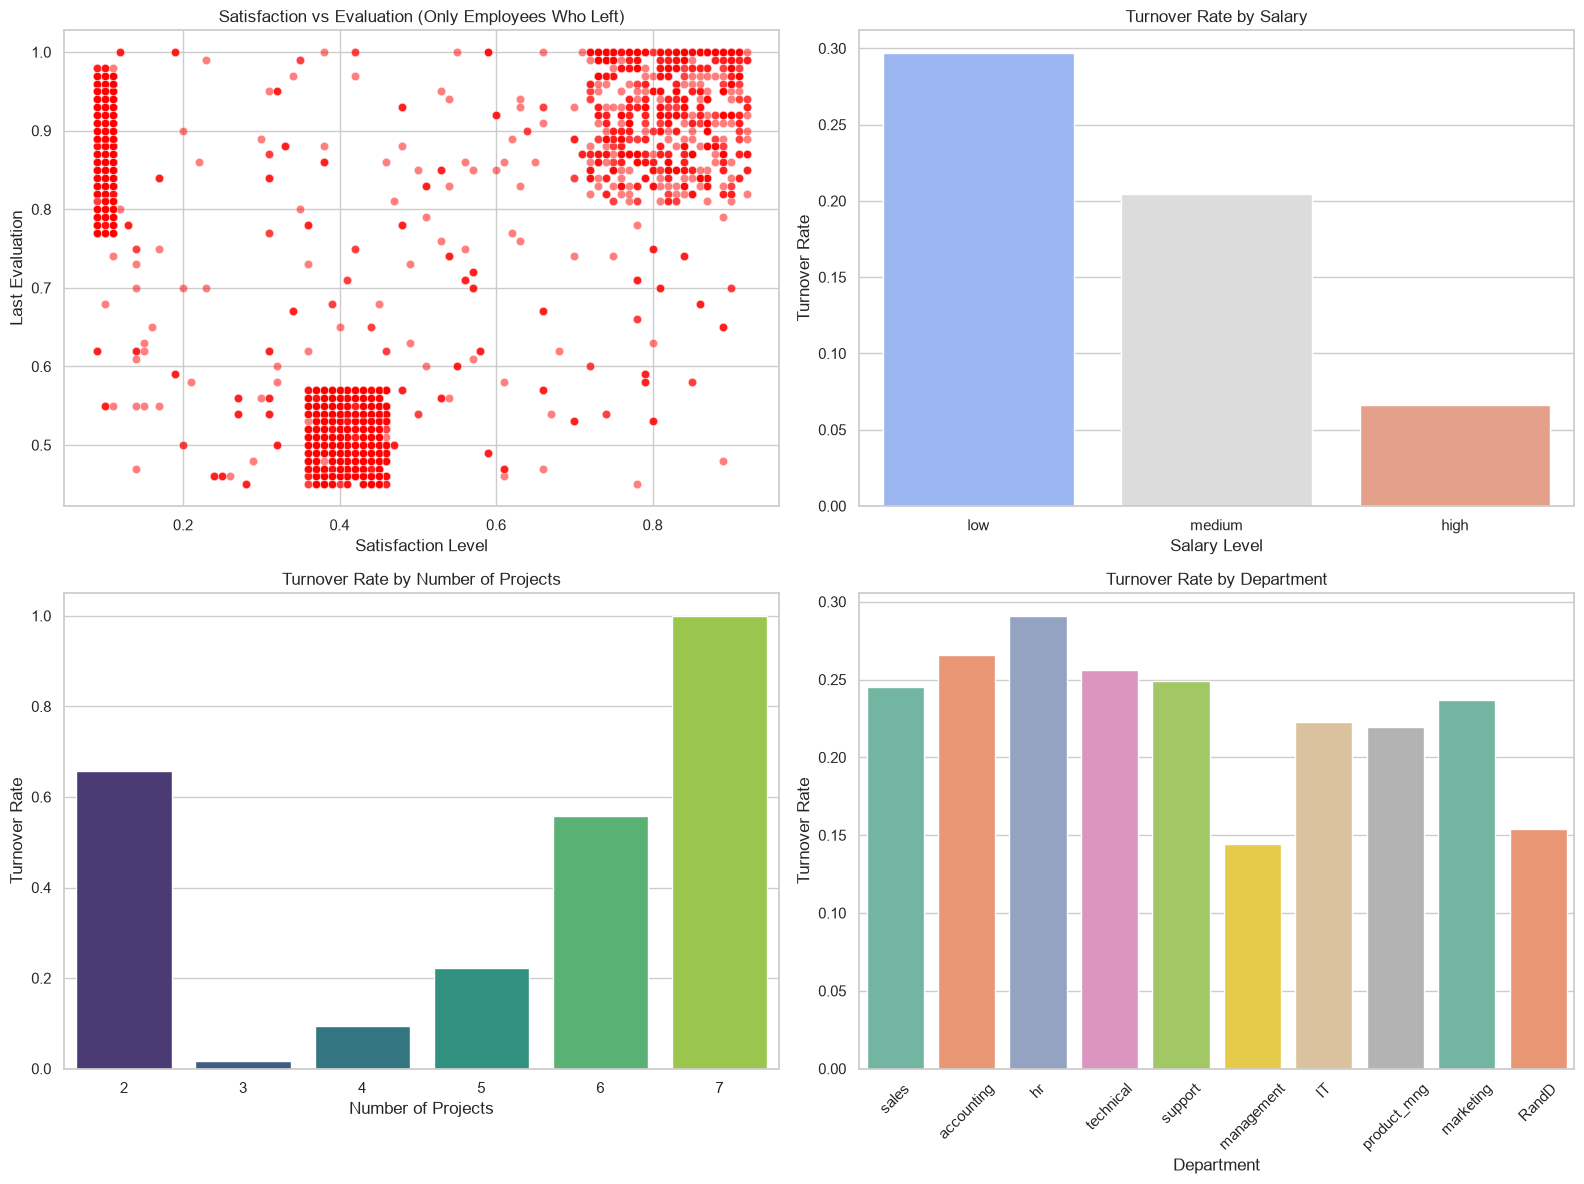

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset from the Excel file
df = pd.read_excel('Datasets/hr_employee_data.xlsx', sheet_name='HR_Employee_Data')

# 2. General Data Overview
print("--- Dataset Shape ---")
print(f"Total employees: {df.shape[0]}")
print(f"Total features: {df.shape[1]}\n")

# Check for missing values
print("--- Missing Values ---")
print(df.isnull().sum())

# Calculate the overall turnover rate
turnover_rate = df['left'].mean()
print(f"\nOverall Turnover Rate: {turnover_rate:.1%}")

# 3. Create clusters to understand WHY people leave based on satisfaction and evaluation
left_df = df[df['left'] == 1]

# Filter out the three distinct groups of employees who leave
burnout = left_df[(left_df['satisfaction_level'] < 0.2) & (left_df['last_evaluation'] > 0.75)]
underperformers = left_df[(left_df['satisfaction_level'] >= 0.3) & (left_df['satisfaction_level'] <= 0.5) & (left_df['last_evaluation'] <= 0.6)]
stars = left_df[(left_df['satisfaction_level'] > 0.7) & (left_df['last_evaluation'] > 0.8)]

print("\n--- Profile of 'Burnout' employees leaving ---")
print(f"Average projects: {burnout['number_project'].mean():.1f}")
print(f"Average monthly hours: {burnout['average_montly_hours'].mean():.0f}")

# 4. Data Visualization 
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot A: Satisfaction vs. Evaluation (The 3 Clusters)
sns.scatterplot(data=left_df, x='satisfaction_level', y='last_evaluation', 
                alpha=0.5, color='red', ax=axes[0, 0])
axes[0, 0].set_title('Satisfaction vs Evaluation (Only Employees Who Left)')
axes[0, 0].set_xlabel('Satisfaction Level')
axes[0, 0].set_ylabel('Last Evaluation')

# Plot B: Turnover by Salary Level
sns.barplot(data=df, x='salary', y='left', order=['low', 'medium', 'high'], 
            errorbar=None, palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Turnover Rate by Salary')
axes[0, 1].set_ylabel('Turnover Rate')
axes[0, 1].set_xlabel('Salary Level')

# Plot C: Turnover by Number of Projects (Workload)
sns.barplot(data=df, x='number_project', y='left', errorbar=None, 
            palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Turnover Rate by Number of Projects')
axes[1, 0].set_ylabel('Turnover Rate')
axes[1, 0].set_xlabel('Number of Projects')

# Plot D: Turnover by Department
sns.barplot(data=df, x='Department', y='left', errorbar=None, 
            palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Turnover Rate by Department')
axes[1, 1].set_ylabel('Turnover Rate')
axes[1, 1].set_xlabel('Department')
axes[1, 1].tick_params(axis='x', rotation=45)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()